In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Thorac - 30-05-2024.txt", delimiter='\t')

In [4]:
df = df.iloc[5: , :]

In [5]:
df

,Signal Type: Sum RIPs-Reference
5,"30.05.2024 20:59:00,000; 13"
6,"30.05.2024 20:59:00,031; 13"
7,"30.05.2024 20:59:00,062; 10"
8,"30.05.2024 20:59:00,094; 11"
9,"30.05.2024 20:59:00,125; 12"
...,...
875184,"31.05.2024 04:34:49,344; -26"
875185,"31.05.2024 04:34:49,375; -25"
875186,"31.05.2024 04:34:49,406; -24"
875187,"31.05.2024 04:34:49,438; -23"


In [9]:
df['Time'] = df['Signal Type: Sum RIPs-Reference'].str.split(';').str[0]
df['Value'] = df['Signal Type: Sum RIPs-Reference'].str.split(';').str[1]

C:\Users\UTSAV\AppData\Local\Temp\ipykernel_18000\3433745321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time'] = df['Signal Type: Sum RIPs-Reference'].str.split(';').str[0]
C:\Users\UTSAV\AppData\Local\Temp\ipykernel_18000\3433745321.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Value'] = df['Signal Type: Sum RIPs-Reference'].str.split(';').str[1]


In [10]:
df

,Signal Type: Sum RIPs-Reference,Time,Value
5,"30.05.2024 20:59:00,000; 13","30.05.2024 20:59:00,000",13
6,"30.05.2024 20:59:00,031; 13","30.05.2024 20:59:00,031",13
7,"30.05.2024 20:59:00,062; 10","30.05.2024 20:59:00,062",10
8,"30.05.2024 20:59:00,094; 11","30.05.2024 20:59:00,094",11
9,"30.05.2024 20:59:00,125; 12","30.05.2024 20:59:00,125",12
...,...,...,...
875184,"31.05.2024 04:34:49,344; -26","31.05.2024 04:34:49,344",-26
875185,"31.05.2024 04:34:49,375; -25","31.05.2024 04:34:49,375",-25
875186,"31.05.2024 04:34:49,406; -24","31.05.2024 04:34:49,406",-24
875187,"31.05.2024 04:34:49,438; -23","31.05.2024 04:34:49,438",-23


In [12]:
thor = pd.DataFrame(columns=['Time', 'Value'], data=df)

In [13]:
thor

,Time,Value
5,"30.05.2024 20:59:00,000",13
6,"30.05.2024 20:59:00,031",13
7,"30.05.2024 20:59:00,062",10
8,"30.05.2024 20:59:00,094",11
9,"30.05.2024 20:59:00,125",12
...,...,...
875184,"31.05.2024 04:34:49,344",-26
875185,"31.05.2024 04:34:49,375",-25
875186,"31.05.2024 04:34:49,406",-24
875187,"31.05.2024 04:34:49,438",-23


In [15]:
thor = thor.set_index('Time')

In [16]:
thor

,Value
Time,
"30.05.2024 20:59:00,000",13
"30.05.2024 20:59:00,031",13
"30.05.2024 20:59:00,062",10
"30.05.2024 20:59:00,094",11
"30.05.2024 20:59:00,125",12
...,...
"31.05.2024 04:34:49,344",-26
"31.05.2024 04:34:49,375",-25
"31.05.2024 04:34:49,406",-24


In [18]:
thor.index = pd.to_datetime(thor.index, format="%d.%m.%Y %H:%M:%S,%f")

In [21]:
thor['Value'] = pd.to_numeric(thor['Value'].astype(str).str.strip(), errors='coerce')

In [23]:
thor_micro = thor.resample('1s').median()

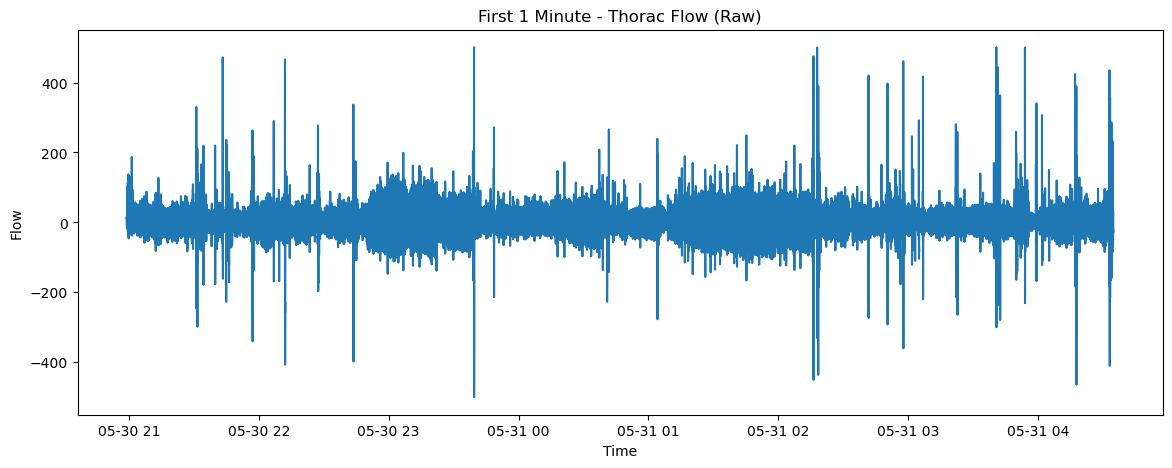

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(thor.index, thor['Value'])
plt.title("First 1 Minute - Thorac Flow (Raw)")
plt.xlabel("Time")
plt.ylabel("Flow")
plt.show()